In [53]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

import geomstats.backend as gs
from geomstats.geometry.stratified.bhv_space import (
    Tree,
    TreeSpace,
)
from geomstats.geometry.stratified.trees import Split
from geomstats.learning.frechet_mean import SturmsMean

gs.random.seed(666)

### Load flow trees ugh

In [54]:
### Load articles and categories
# /Users/abbybertics/Documents/ucsb/mazedyn
# /Users/abbybertics/Documents/ucsb/geomstats/geomstats
data_path = "../../../mazedyn/mazedyn/data/wikispeedia_paths-and-graph"

# load article names
article_names = []
with open(f"{data_path}/articles.tsv") as f:
    for line in f:
        line = line.strip()
        if len(line) == 0 or line[0] == "#":
            continue

        # decoded_line = urllib.parse.unquote(line)
        # maybe leave in URL encoding bc the
        article_names.append(line)

# load shortest paths


def get_nth_category(category_string, n):
    category_list = category_string.split(".")
    if len(category_list) <= n:
        return pd.NA
    return category_list[n]


# load categories
column_names = ["article", "category"]
categories_df = pd.read_csv(
    f"{data_path}/categories.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(13)],
)
categories_df["num_categories"] = categories_df["category"].apply(
    lambda x: len(x.split("."))
)
print("Max category depth is", categories_df["num_categories"].max())
for i in range(categories_df["num_categories"].max()):
    categories_df[f"category{i}"] = categories_df["category"].apply(
        lambda x: get_nth_category(x, i)
    )
categories_df


def get_nth_article(article_string, n):
    article_list = article_string.split(";")
    return article_list[n]


def get_path_len(x):
    return len(x.split(";"))


def get_least_common_level(art1, art2):
    art1_row = categories_df[categories_df["article"] == art1]
    art2_row = categories_df[categories_df["article"] == art2]

    if len(art1_row) == 0 or len(art2_row) == 0:
        return None

    lcl = None
    for i in range(max_category_depth):
        art1_cat = art1_row[f"category{i}"].iloc[0]
        art2_cat = art2_row[f"category{i}"].iloc[
            0
        ]  # sometimes there are two categories got to fix

        if pd.isna(art1_cat) or pd.isna(art2_cat) or art1_cat != art2_cat:
            return lcl
        else:
            lcl = i
    return lcl

    # for i in range([f"category{i}"]


def get_levels_traj(x):
    articles = x.split(";")
    traj = []
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i - 1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(category_level_dict.get(articles[j], None))
                    break
        else:
            traj.append(category_level_dict.get(article, None))
    return traj


def get_level_hops(x):
    articles = x.split(";")
    traj = []
    for i, article in enumerate(articles):
        if article == "<":
            # this means back click!
            for j in range(i - 1, 0, -1):
                # sometimes more than one in a row
                if articles[j] != "<":
                    traj.append(articles[j])
                    break
        else:
            traj.append(article)

    lcls = []
    for i in range(len(traj) - 1):
        a, b = traj[i], traj[i + 1]
        lcls.append(get_least_common_level(a, b))
    return lcls


# load successful trajectories
column_names = ["hashedIpAddress", "timestamp", "durationInSec", "path", "rating"]
finished_trajs_df = pd.read_csv(
    f"{data_path}/paths_finished.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(16)],
)
finished_trajs_df["StartAt"] = finished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, 0)
)
finished_trajs_df["EndAt"] = finished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, -1)
)
finished_trajs_df["finished"] = True

# load unsuccessful trajectories
column_names = [
    "hashedIpAddress",
    "timestamp",
    "durationInSec",
    "path",
    "target",
    "type",
]
unfinished_trajs_df = pd.read_csv(
    f"{data_path}/paths_unfinished.tsv",
    names=column_names,
    sep="\t",
    skiprows=[i for i in range(17)],
)
unfinished_trajs_df["StartAt"] = unfinished_trajs_df["path"].apply(
    lambda x: get_nth_article(x, 0)
)
unfinished_trajs_df["EndAt"] = unfinished_trajs_df["target"]
unfinished_trajs_df["finished"] = False

trajs_df = pd.concat([finished_trajs_df, unfinished_trajs_df])
trajs_df.reset_index()
trajs_df["traj_len"] = trajs_df["path"].apply(get_path_len)
# trajs_df["levels_traj"] = trajs_df["path"].apply(get_levels_traj)
# trajs_df["level_hops"] = trajs_df["path"].apply(get_level_hops)

# don't want multiple attempts for each person
print("Shape before dupes removed", trajs_df.shape)
trajs_df = trajs_df.drop_duplicates(subset=["hashedIpAddress", "StartAt", "target"])

print("Shape after", trajs_df.shape)


def process_path(path):
    # Longest backclick sequence is 22 <;<;<;<;<;<;<;<;<;<;<;<;<;<;< + more
    # print(path)
    assert ";<" * 23 not in path

    for i in range(21, 0, -1):
        backtrack_seq = "<" + ";<" * i
        if backtrack_seq in path:
            path = path.replace(backtrack_seq, f"<{i + 1}")

    split_path = path.split(";")
    real_nodes = []
    for i, node in enumerate(split_path):
        if "<" in node:
            bktrk = 1 if node == "<" else int(node[1:])
            node = real_nodes[i - bktrk - 1]
        real_nodes.append(node)

    return real_nodes


trajs_df["traj"] = trajs_df["path"].apply(process_path)
trajs_df["StartEnd"] = trajs_df["StartAt"] + "_" + trajs_df["EndAt"]

trajs_df["accuracy"] = trajs_df.groupby("StartEnd")["finished"].transform("mean")
trajs_df["avg_rating"] = trajs_df.groupby("StartEnd")["rating"].transform("mean")

trajs_df[["StartEnd", "traj", "accuracy", "avg_rating"]]

Max category depth is 4
Shape before dupes removed (76193, 11)
Shape after (70770, 11)


,StartEnd,traj,accuracy,avg_rating
0,14th_century_African_slave_trade,"[14th_century, 15th_century, 16th_century, Pac...",0.428571,3.0
1,14th_century_African_slave_trade,"[14th_century, Europe, Africa, Atlantic_slave_...",0.428571,3.0
2,14th_century_African_slave_trade,"[14th_century, Niger, Nigeria, British_Empire,...",0.428571,3.0
3,14th_century_Greece,"[14th_century, Renaissance, Ancient_Greece, Gr...",1.000000,NaN
4,14th_century_John_F._Kennedy,"[14th_century, Italy, Roman_Catholic_Church, H...",1.000000,3.0
...,...,...,...,...
24870,Franz_Kafka_Cholera,"[Franz_Kafka, Tuberculosis, World_Health_Organ...",0.000000,NaN
24871,Modern_history_Hollandic,[Modern_history],0.000000,NaN
24872,Computer_programming_The_Beatles,"[Computer_programming, Linguistics, Culture, P...",0.533333,4.0
24873,Jamaica_Alan_Turing,"[Jamaica, United_Kingdom, World_War_II, Battle...",0.000000,NaN


In [55]:
# find most common paths
k = 50
path_counts = trajs_df.groupby(["StartEnd"]).size().sort_values(ascending=False)
most_common_paths = path_counts[:k].index.tolist()

[({0, 5, 6, 7, 9}, {1, 2, 3, 4, 8, 10}), ({0, 1, 2, 4, 5, 6, 7, 9, 10}, {8, 3}), ({0, 6}, {1, 2, 3, 4, 5, 7, 8, 9, 10}), ({0, 1, 2, 3, 4, 6, 7, 8, 10}, {9, 5})]
[(0, 5, 6, 7, 9), (8, 3), (0, 6), (9, 5)] [1, 1, 1, 4] [3, 18, 13, 3, 6, 1, 8, 5, 4, 1, 1]
(({0, 5, 6, 7, 9}|{1, 2, 3, 4, 8, 10}, {0, 1, 2, 3, 4, 6, 7, 8, 10}|{9, 5}, {0, 6}|{1, 2, 3, 4, 5, 7, 8, 9, 10}, {0, 1, 2, 4, 5, 6, 7, 9, 10}|{8, 3});[1 4 1 1])


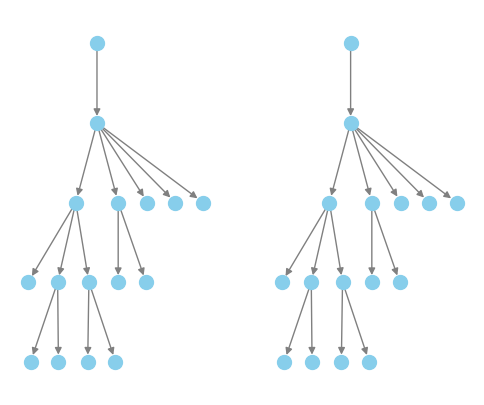

In [56]:
def generate_flow_tree_splits_from_trajs(trajs, DEBUG=False):
    """Generate Flow Tree splits from trajectories.

    Assume labels are {0...n_trajs}, with n_trajs being the root node.
    """
    labels_running_trajs_dict = {traj_label: "" for traj_label in range(len(trajs))}
    max_traj_len = max([len(traj) for traj in trajs])

    splits_lengths_dict, time_to_first_split = {}, 0
    for index in range(1, max_traj_len + 1):
        up_til_now_trajs = []
        to_delete = []
        for traj_label in labels_running_trajs_dict:
            this_traj = trajs[traj_label]
            if index > len(this_traj):
                to_delete.append(traj_label)
            else:
                labels_running_trajs_dict[traj_label] = "#".join(
                    [this_traj[i] for i in range(index)]
                )

        for x in to_delete:
            del labels_running_trajs_dict[x]
        if DEBUG:
            print(up_til_now_trajs)

        # See if can split into groups
        up_til_now_splits = {}
        for traj_label, running_traj in labels_running_trajs_dict.items():
            current_split = up_til_now_splits.get(running_traj, set())
            current_split.add(traj_label)

            up_til_now_splits[running_traj] = current_split

        if DEBUG:
            print(up_til_now_splits)

        for up_till_now_traj, this_split in up_til_now_splits.items():
            if DEBUG:
                print(this_split)
            # Singleton will yield pendant edge corresponding to how far that person went alone!
            if len(this_split) == len(trajs):
                time_to_first_split += 1
            elif len(this_split) == 1:
                (to_delete,) = this_split
                del labels_running_trajs_dict[to_delete]
            else:
                splits_lengths_dict[tuple(this_split)] = (
                    splits_lengths_dict.get(tuple(this_split), 0) + 1
                )

        if DEBUG:
            print("splits_lengths_dict", splits_lengths_dict)
        if DEBUG:
            print("traj indx left:", labels_running_trajs_dict)

    splits, lengths = [], []
    for spl, ln in splits_lengths_dict.items():
        splits.append(spl)
        lengths.append(ln)

    pendant_edges = []
    for i in range(len(trajs)):
        pendant_edges.append(len(trajs[i]))
    pendant_edges.append(time_to_first_split)

    for lbl, ew in enumerate(pendant_edges):
        smol_ln = ew
        for split, ln in zip(splits, lengths):
            if lbl in split:
                smol_ln -= ln
        pendant_edges[lbl] = smol_ln

    return splits, lengths, pendant_edges


def convert_to_bhv_tree(splits, lengths, pendant_edges):
    labels = set(range(len(pendant_edges)))

    all_splits = []
    for split in splits:
        parta = set(split)
        all_splits.append(Split(parta, labels - parta))

    return Tree(all_splits, lengths)


def convert_to_bhv_tree(splits, lengths, pendant_edges):
    labels = set(range(len(pendant_edges)))

    all_splits = []
    for split in splits:
        parta = set(split)
        all_splits.append(Split(parta, labels - parta))
    print(all_splits)
    if not all_splits or (len(all_splits) == 0):
        return Tree([], [], n_labels=len(pendant_edges))
    return Tree(all_splits, lengths)


def convert_bhv_tree_to_networkx(tree, pendant_edges):
    # order splits by non-root-containing
    root_id = len(pendant_edges) - 1
    splits = []
    for ft_split_pair in tree.topology.splits:
        p1, p2 = ft_split_pair.part1, ft_split_pair.part2
        if root_id in p2:
            splits.append(tuple(p1))
        else:
            splits.append(tuple(p2))
    lengths = tree.lengths

    return convert_splits_to_networkx(splits, lengths, pendant_edges, DEBUG=False)


def convert_splits_to_networkx(splits, lengths, pendant_edges, DEBUG=False):
    G = nx.DiGraph()

    n_leaves = len(pendant_edges) - 1
    leaf_labels = tuple(range(n_leaves))
    G.add_nodes_from(leaf_labels)

    inner_labels = [tuple(split) for split in splits]
    G.add_nodes_from(inner_labels)

    if DEBUG:
        print("SPLITS", splits)

    # Root pendant edge
    G.add_node(-1)
    G.add_node(leaf_labels)
    G.add_edge(-1, leaf_labels, length=pendant_edges[-1], weight=len(leaf_labels))
    if DEBUG:
        print("ADDING EDGE", -1, leaf_labels)

    # Pendant edges
    for i, pendant_edge in enumerate(pendant_edges[:-1]):
        # find smallest subset she is in!
        smallest_node, node_size = leaf_labels, n_leaves
        for node in splits:
            if i in node:
                if len(node) < node_size:
                    smallest_node = node
                    node_size = len(node)
        if DEBUG:
            print("ADDING EDGE", i, smallest_node)
        G.add_edge(tuple(smallest_node), i, length=pendant_edge, weight=1)

    # Splits
    for split, split_length in zip(splits, lengths):
        # find smallest subset she is in!
        smallest_node, node_size = leaf_labels, n_leaves
        for node in splits:
            if set(split) < set(node):
                if len(node) < node_size:
                    smallest_node = node
                    node_size = len(node)

        if DEBUG:
            print("ADDING EDGE", split, smallest_node)

        G.add_edge(tuple(smallest_node), split, length=split_length, weight=len(split))

    return G


fig, axes = plt.subplots(1, 2, figsize=(6, 5))
fewest_attempts = 10
for j, start_end in enumerate(most_common_paths):
    this_df = trajs_df[(trajs_df["StartEnd"] == start_end) & (trajs_df["traj_len"] > 3)]

    sampled_trajs = this_df["traj"].to_numpy()
    if len(sampled_trajs) > fewest_attempts:
        sampled_indices = np.random.choice(
            len(sampled_trajs), size=fewest_attempts, replace=False
        )
        sampled_trajs = [sampled_trajs[i] for i in sampled_indices]

    ## Split-based representation
    splits, lengths, pendant_edges = generate_flow_tree_splits_from_trajs(
        sampled_trajs, DEBUG=False
    )
    flow_tree = convert_to_bhv_tree(splits, lengths, pendant_edges)
    print(splits, lengths, pendant_edges)
    print(flow_tree)

    other_G = convert_splits_to_networkx(splits, lengths, pendant_edges)
    pos = nx.nx_agraph.graphviz_layout(other_G, prog="dot", root=-1)
    nx.draw(
        other_G,
        pos,
        ax=axes[j],
        with_labels=False,
        node_size=100,
        node_color="skyblue",
        font_size=10,
        edge_color="gray",
    )

    back_to_nx = convert_bhv_tree_to_networkx(flow_tree, pendant_edges)
    pos = nx.nx_agraph.graphviz_layout(back_to_nx, prog="dot", root=-1)
    nx.draw(
        back_to_nx,
        pos,
        ax=axes[j + 1],
        with_labels=False,
        node_size=100,
        node_color="skyblue",
        font_size=10,
        edge_color="gray",
    )
    if j == 0:
        break

plt.show()

In [57]:
trees_by_path = {}

fewest_attempts = 5
for j, start_end in enumerate(most_common_paths):
    this_df = trajs_df[(trajs_df["StartEnd"] == start_end) & (trajs_df["traj_len"] > 3)]

    sampled_trajs = this_df["traj"].to_numpy()
    if len(sampled_trajs) > fewest_attempts:
        sampled_indices = np.random.choice(
            len(sampled_trajs), size=fewest_attempts, replace=False
        )
        sampled_trajs = [sampled_trajs[i] for i in sampled_indices]

    ## Split-based representation
    splits, lengths, pendant_edges = generate_flow_tree_splits_from_trajs(
        sampled_trajs, DEBUG=False
    )
    flow_tree = convert_to_bhv_tree(splits, lengths, pendant_edges)
    # print(len(pendant_edges))
    trees_by_path[start_end] = flow_tree

[({0, 3, 5}, {1, 2, 4}), ({0, 1, 3, 5}, {2, 4})]
[]
[({0, 1, 3, 5}, {2, 4})]
[({0, 1, 4}, {2, 3, 5})]
[({0, 3, 4}, {1, 2, 5})]
[({0, 4}, {1, 2, 3, 5})]
[({0, 1}, {2, 3, 4, 5}), ({0, 1, 4, 5}, {2, 3})]
[({0, 3}, {1, 2, 4, 5}), ({0, 3, 5}, {1, 2, 4})]
[({0, 2, 4, 5}, {1, 3}), ({0, 1, 3, 5}, {2, 4})]
[({0, 3, 4}, {1, 2, 5})]
[({0, 1, 2, 5}, {3, 4})]
[({0, 2}, {1, 3, 4, 5})]
[({0, 3, 4}, {1, 2, 5}), ({0, 4}, {1, 2, 3, 5})]
[({0, 1, 4, 5}, {2, 3})]
[({0, 1, 2, 4}, {3, 5}), ({0, 2}, {1, 3, 4, 5})]
[({0, 2}, {1, 3, 4, 5})]
[({0, 3}, {1, 2, 4, 5})]
[({0, 1}, {2, 3, 4, 5})]
[({0, 1, 2}, {3, 4, 5})]
[({0, 2}, {1, 3, 4, 5}), ({0, 2, 3, 5}, {1, 4})]
[({0, 2, 3, 5}, {1, 4}), ({0, 1, 4, 5}, {2, 3})]
[]
[({0, 4}, {1, 2, 3, 5}), ({0, 1, 4, 5}, {2, 3})]
[({0, 4, 5}, {1, 2, 3})]
[({0, 5}, {1, 2, 3, 4}), ({0, 2, 3, 5}, {1, 4})]
[({0, 1}, {2, 3, 4, 5}), ({0, 1, 5}, {2, 3, 4}), ({0, 1, 2, 5}, {3, 4})]
[({0, 1}, {2, 3, 4, 5}), ({0, 1, 3, 5}, {2, 4})]
[({0, 1, 4}, {2, 3, 5})]
[({0, 3, 4}, {1, 2, 5}), ({0, 3,

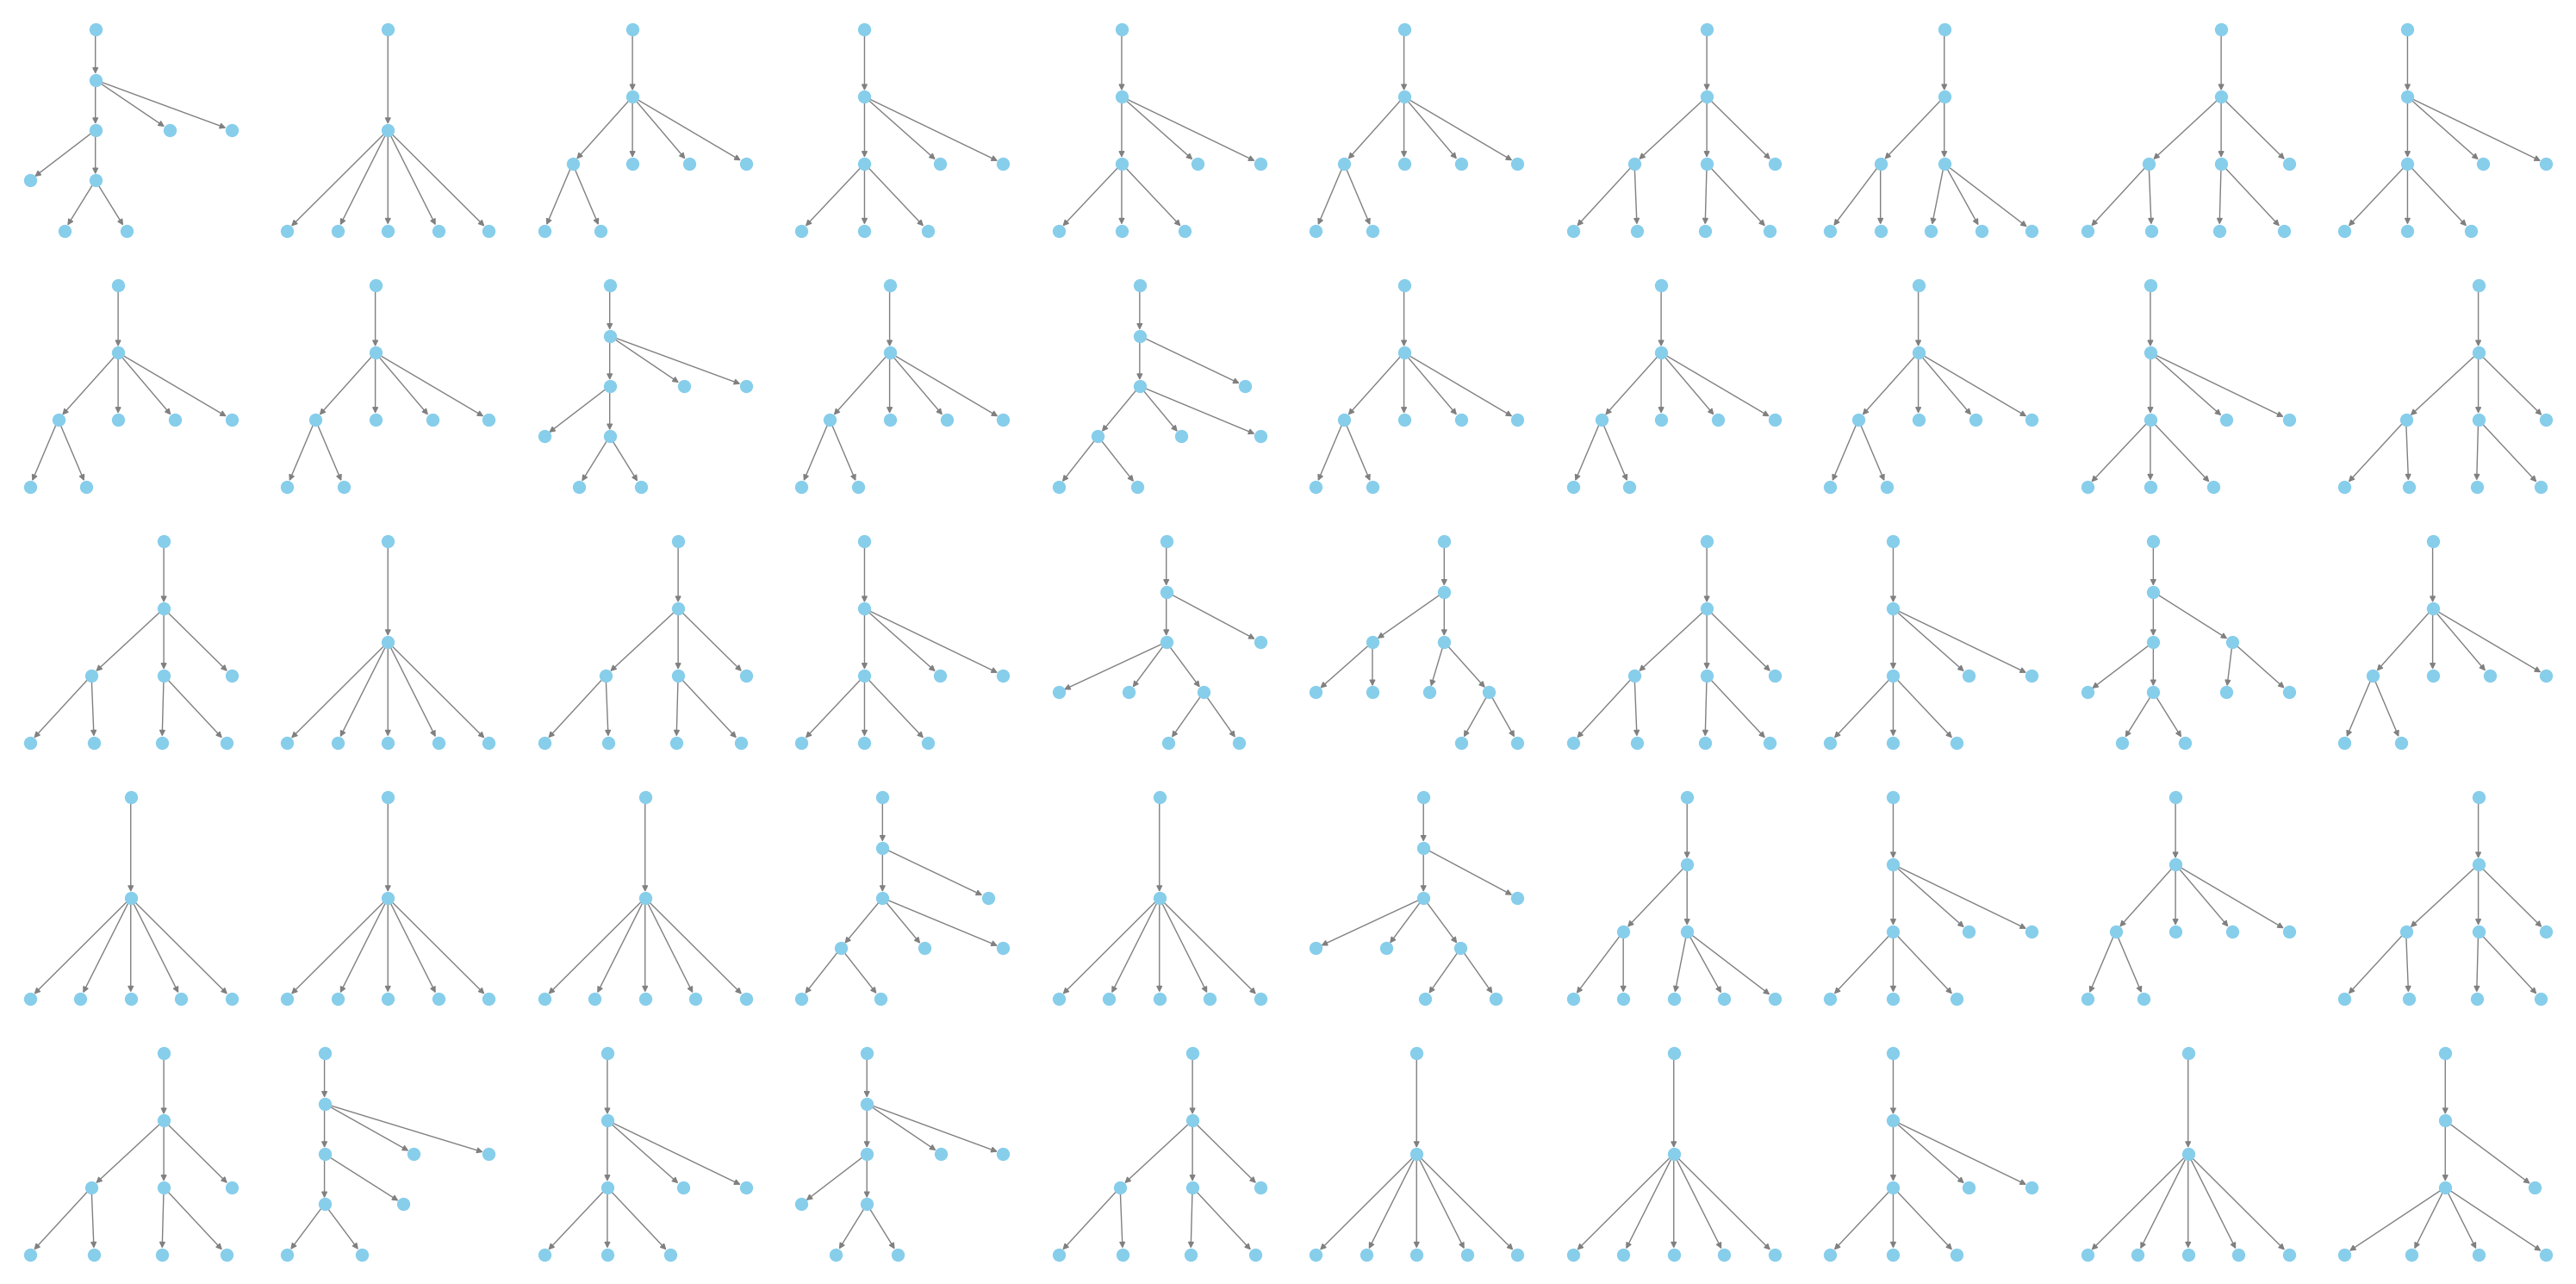

In [6]:
if False:
    n_cols = 10
    fig, axes = plt.subplots(
        5, n_cols, figsize=(30, 15)
    )  # , facecolor=hex_to_rgb_add_alpha("FF5A5F", 0.3))
    for i, (start_end) in enumerate(most_common_paths):
        flow_tree = trees_by_path[start_end]

        ax = axes[i // n_cols][i % n_cols]
        back_to_nx = convert_bhv_tree_to_networkx(flow_tree, pendant_edges)
        pos = nx.nx_agraph.graphviz_layout(back_to_nx, prog="dot", root=-1)
        nx.draw(
            back_to_nx,
            pos,
            ax=ax,
            with_labels=False,
            node_size=100,
            node_color="skyblue",
            font_size=10,
            edge_color="gray",
        )

    plt.tight_layout()
    plt.show()

### Compute mean

In [58]:
bhv_ft = TreeSpace(n_labels=fewest_attempts + 1)  # for root

bhv_ft.equip_with_group_action()
bhv_ft.equip_with_quotient()

sturms_mean = SturmsMean(bhv_ft, max_iter=3000, align_iter=4, epsilon=1e-3)

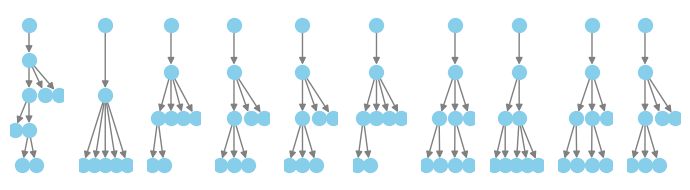

In [60]:
# Visualise trees
trees = np.array([x for x in trees_by_path.values()])[:10]

n_cols = len(trees)
fig, axes = plt.subplots(1, n_cols, figsize=(7, 2))
for i, (tree) in enumerate(trees):
    ax = axes[i]
    back_to_nx = convert_bhv_tree_to_networkx(tree, [1 for _ in range(6)])
    pos = nx.nx_agraph.graphviz_layout(back_to_nx, prog="dot", root=-1)
    nx.draw(
        back_to_nx,
        pos,
        ax=ax,
        with_labels=False,
        node_size=100,
        node_color="skyblue",
        font_size=10,
        edge_color="gray",
    )

plt.tight_layout()
plt.show()

In [61]:
# Estimate mean without alignment
mean_estimate_no_alignment = sturms_mean.fit(trees, verbose=False).estimate_
print("Min distance:", sturms_mean.procrustes_obj(trees, mean_estimate_no_alignment))
print("Mean estimate:", mean_estimate_no_alignment)

Min distance: 15.040725006101706
Mean estimate: [((({0, 3}, {1, 2, 4, 5}), ({0, 3, 5}, {1, 2, 4}), ({0, 1, 3, 5}, {2, 4})), (np.float64(0.00041882477814439656), np.float64(0.0013275057135978521), np.float64(0.0006764939786052784)))]


In [62]:
# Estimate mean with alignment
mean_estimate_with_alignment = sturms_mean.align_and_fit(trees).estimate_

print("Min distance:", sturms_mean.procrustes_obj(trees, mean_estimate_with_alignment))
print("Mean estimate:", mean_estimate_with_alignment)

Min distance: 12.325428085302358
Mean estimate: [((({0, 3, 5}, {1, 2, 4}), ({0, 1, 3, 5}, {2, 4})), (np.float64(0.6987075928917603), np.float64(0.900646203554119)))]


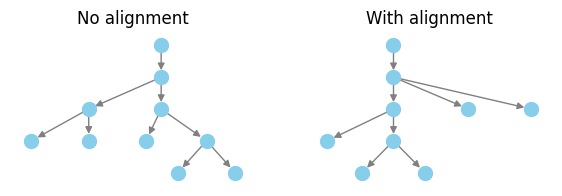

In [63]:
# Visualise means
fig, axes = plt.subplots(1, 2, figsize=(7, 2))

mean_estimate_no_alignment_nx = convert_bhv_tree_to_networkx(
    mean_estimate_no_alignment[0], [1 for _ in range(6)]
)
pos = nx.nx_agraph.graphviz_layout(mean_estimate_no_alignment_nx, prog="dot", root=-1)
nx.draw(
    mean_estimate_no_alignment_nx,
    pos,
    ax=axes[0],
    with_labels=False,
    node_size=100,
    node_color="skyblue",
    font_size=10,
    edge_color="gray",
)
axes[0].set_title("No alignment")

mean_estimate_with_alignment_nx = convert_bhv_tree_to_networkx(
    mean_estimate_with_alignment[0], [1 for _ in range(6)]
)
pos = nx.nx_agraph.graphviz_layout(mean_estimate_with_alignment_nx, prog="dot", root=-1)
nx.draw(
    mean_estimate_with_alignment_nx,
    pos,
    ax=axes[1],
    with_labels=False,
    node_size=100,
    node_color="skyblue",
    font_size=10,
    edge_color="gray",
)
axes[1].set_title("With alignment")


plt.show()

### Various sanity checks

#### |N| = 4 

In [2]:
total_space = TreeSpace(n_labels=4)
total_space.equip_with_group_action()
label_invariant_tree_space = total_space.equip_with_quotient()

# 1 and 2 are switched
tree_topo = (Split({0, 1}, {2, 3}),)
permuted_tree_topo = (Split({0, 2}, {1, 3}),)

tree = Tree(tree_topo, [1])
shifted_tree = Tree(tree_topo, [2])
permuted_tree = Tree(permuted_tree_topo, [1])

aligned_permuted_tree = total_space.aligner.align(permuted_tree, tree)
aligned_permuted_tree_to_shifted = total_space.aligner.align(
    permuted_tree, shifted_tree
)
shifted_aligned = total_space.aligner.align(shifted_tree, tree)

print("Tree", tree)
print("Shifted tree", shifted_tree)
print("Permuted tree", permuted_tree)
print("Permuted aligned to tree", aligned_permuted_tree)
print("Permuted aligned to shifted tree", aligned_permuted_tree_to_shifted)
print("Shifted aligned to tree", shifted_aligned)

Tree (({0, 1}|{2, 3});[1])
Shifted tree (({0, 1}|{2, 3});[2])
Permuted tree (({0, 2}|{1, 3});[1])
Permuted aligned to tree (({0, 1}|{2, 3});[1])
Permuted aligned to shifted tree (({0, 1}|{2, 3});[1])
Shifted aligned to tree (({0, 1}|{2, 3});[2])


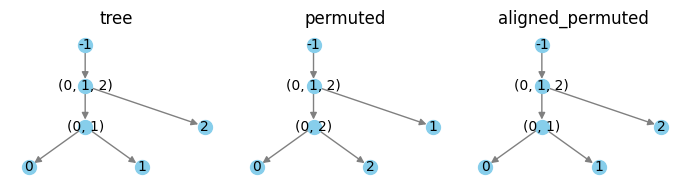

In [ ]:
# Visualise
trees = [tree, permuted_tree, aligned_permuted_tree]
tree_names = ["tree", "permuted", "aligned_permuted"]
n_cols = len(trees)
fig, axes = plt.subplots(1, n_cols, figsize=(7, 2))
for i, (tree) in enumerate(trees):
    ax = axes[i]
    back_to_nx = convert_bhv_tree_to_networkx(tree, [1 for _ in range(4)])
    pos = nx.nx_agraph.graphviz_layout(back_to_nx, prog="dot", root=-1)
    nx.draw(
        back_to_nx,
        pos,
        ax=ax,
        with_labels=True,
        node_size=100,
        node_color="skyblue",
        font_size=10,
        edge_color="gray",
    )
    ax.set_title(tree_names[i])

plt.tight_layout()
plt.show()

#### |N| = 5

In [39]:
total_space = TreeSpace(n_labels=5)
total_space.equip_with_group_action()
label_invariant_tree_space = total_space.equip_with_quotient()

# 3 and 1 are switched
tree_topo = (Split({3, 4}, {0, 1, 2}), Split({0, 1}, {2, 3, 4}))
permuted_tree_topo = (Split({1, 4}, {0, 3, 2}), Split({0, 3}, {2, 1, 4}))
subset_permuted_tree_topo = (Split({3, 1}, {0, 2, 4}),)
lengths = gs.array([1, 2])

tree = Tree(tree_topo, lengths)
shifted_tree = Tree(tree_topo, lengths + 0.5)
permuted_tree = Tree(permuted_tree_topo, lengths)
subset_permuted_tree = Tree(subset_permuted_tree_topo, [1])

aligned_permuted_tree = total_space.aligner.align(permuted_tree, tree)
aligned_subset_permuted_tree = total_space.aligner.align(subset_permuted_tree, tree)
othe_aligned_subset_permuted_tree = total_space.aligner.align(
    subset_permuted_tree, permuted_tree
)

print("Tree", tree)
print("Permuted tree", permuted_tree)
print("Subset permuted tree", subset_permuted_tree)
print("Permuted aligned to tree", aligned_permuted_tree)
print("Subset permuted aligned to tree", aligned_subset_permuted_tree)
print("Subset permuted aligned to permuted", othe_aligned_subset_permuted_tree)

Tree (({0, 1, 2}|{3, 4}, {0, 1}|{2, 3, 4});[1 2])
Permuted tree (({0, 2, 3}|{1, 4}, {0, 3}|{1, 2, 4});[1 2])
Subset permuted tree (({0, 2, 4}|{1, 3});[1])
Permuted aligned to tree (({0, 1, 2}|{3, 4}, {0, 1}|{2, 3, 4});[1 2])
Subset permuted aligned to tree (({0, 1}|{2, 3, 4});[1])
Subset permuted aligned to permuted (({0, 3}|{1, 2, 4});[1])


In [27]:
print(total_space.metric.dist(tree, permuted_tree))
print(total_space.metric.dist(tree, aligned_permuted_tree))
print(label_invariant_tree_space.metric.dist(tree, permuted_tree))

3.23606797749979
1.4142135623730951
1.4142135623730951


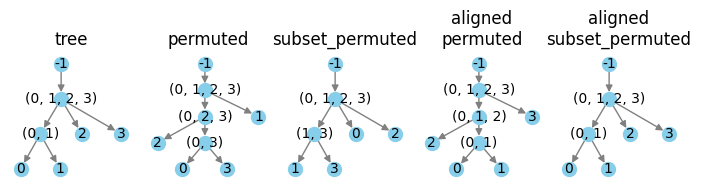

In [25]:
# Visualise
trees = [
    tree,
    permuted_tree,
    subset_permuted_tree,
    aligned_permuted_tree,
    aligned_subset_permuted_tree,
]
tree_names = [
    "tree",
    "permuted",
    "subset_permuted",
    "aligned\npermuted",
    "aligned\nsubset_permuted",
]
n_cols = len(trees)
fig, axes = plt.subplots(1, n_cols, figsize=(7, 2))
for i, (tree) in enumerate(trees):
    ax = axes[i]
    back_to_nx = convert_bhv_tree_to_networkx(tree, [1 for _ in range(5)])
    pos = nx.nx_agraph.graphviz_layout(back_to_nx, prog="dot", root=-1)
    nx.draw(
        back_to_nx,
        pos,
        ax=ax,
        with_labels=True,
        node_size=100,
        node_color="skyblue",
        font_size=10,
        edge_color="gray",
    )
    ax.set_title(tree_names[i])

plt.tight_layout()
plt.show()

In [30]:
fm = SturmsMean(total_space, epsilon=1e-3, max_iter=1000, align_iter=4)

In [49]:
boring_trees = np.array([tree, tree, shifted_tree, shifted_tree])

est = fm.fit(boring_trees).estimate_[0]
print(fm.procrustes_obj(boring_trees, est))
print(est)

# [((({0, 1, 2}, {3, 4}), ({0, 1}, {2, 3, 4})), (np.float64(1.1666666666666667), np.float64(2.1666666666666656)))]

1.414213562373095
(({0, 1, 2}|{3, 4}, {0, 1}|{2, 3, 4});[1.25069638 2.25069638])


In [50]:
trees = np.array([tree, shifted_tree, permuted_tree, permuted_tree])

est_without_align = fm.fit(trees).estimate_[0]
print(fm.procrustes_obj(trees, est_without_align))
print(est_without_align)

est_with_align = fm.align_and_fit(trees).estimate_[0]
print(fm.procrustes_obj(trees, est_with_align))
print(est_with_align)

8.956858257396638
(({0, 1, 2}|{3, 4}, {0, 1}|{2, 3, 4});[0.08103321 0.14585979])
1.0620466556645007
(({0, 1, 2}|{3, 4}, {0, 1}|{2, 3, 4});[1.1254902 2.1254902])


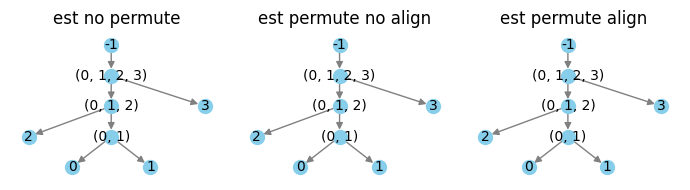

In [ ]:
# Visualise
trees = [est, est_without_align, est_with_align]
tree_names = ["est no permute", "est permute no align", "est permute align"]
n_cols = len(trees)
fig, axes = plt.subplots(1, n_cols, figsize=(7, 2))
for i, (tr) in enumerate(trees):
    ax = axes[i]
    back_to_nx = convert_bhv_tree_to_networkx(tr, [1 for _ in range(5)])
    pos = nx.nx_agraph.graphviz_layout(back_to_nx, prog="dot", root=-1)
    nx.draw(
        back_to_nx,
        pos,
        ax=ax,
        with_labels=True,
        node_size=100,
        node_color="skyblue",
        font_size=10,
        edge_color="gray",
    )
    ax.set_title(tree_names[i])

plt.tight_layout()
plt.show()